In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from sqlalchemy import create_engine, text

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["font.size"] = 11

engine = create_engine(f"sqlite:///{os.path.expanduser('~/credit-cycle-analysis/data/fred_data.db')}")

df = pd.read_sql(text("SELECT * FROM macro_series ORDER BY date"),
                 con=engine.connect())

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.resample("MS").mean()
df = df.ffill()
df = df.dropna()

print(f"Data loaded: {len(df)} rows")

Data loaded: 426 rows


In [2]:
# Define each hiking cycle with start and end dates
hiking_cycles = {
    "1994–95": ("1994-02-01", "1995-02-01"),
    "1999–00": ("1999-06-01", "2000-05-01"),
    "2004–06": ("2004-06-01", "2006-06-01"),
    "2015–18": ("2015-12-01", "2018-12-01"),
    "2022–23": ("2022-03-01", "2023-07-01"),
}

# For each cycle, extract the data and normalise it to start at 0
# This lets us compare cycles on the same chart regardless of absolute levels
def extract_cycle(df, start, end, col):
    cycle = df.loc[start:end, col].copy()
    cycle = cycle - cycle.iloc[0]  # Normalise: subtract starting value
    cycle.index = range(len(cycle))  # Reset index to months since start
    return cycle

print("Cycles defined:")
for name, (start, end) in hiking_cycles.items():
    cycle_df = df.loc[start:end]
    rate_change = df.loc[end, "fed_funds_rate"] - df.loc[start, "fed_funds_rate"]
    print(f"  {name}: {len(cycle_df)} months | Rate change: +{rate_change:.2f}%")

Cycles defined:
  1994–95: 13 months | Rate change: +2.67%
  1999–00: 12 months | Rate change: +1.51%
  2004–06: 25 months | Rate change: +3.96%
  2015–18: 37 months | Rate change: +2.03%
  2022–23: 17 months | Rate change: +4.92%


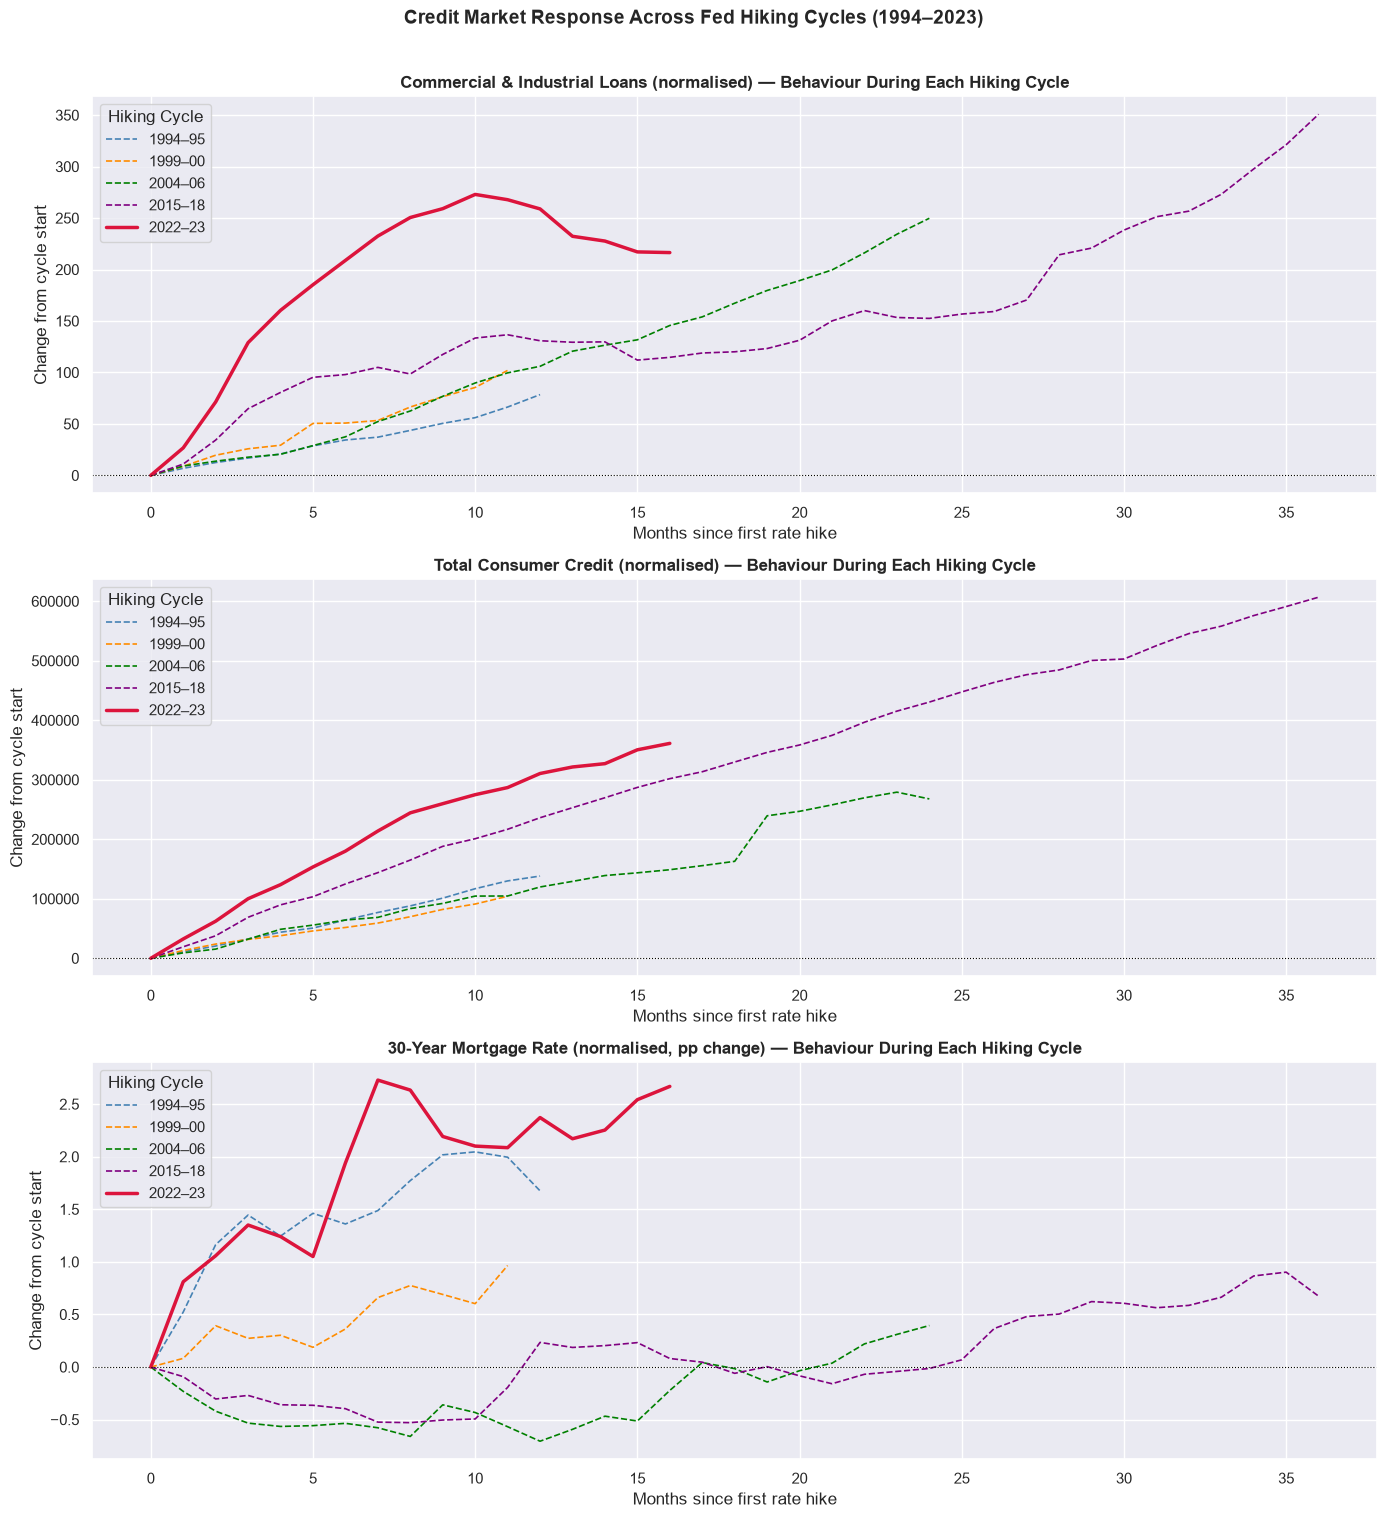

Chart saved.


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False)

series_to_compare = [
    ("commercial_loans",   "Commercial & Industrial Loans (normalised)"),
    ("consumer_credit",    "Total Consumer Credit (normalised)"),
    ("mortgage_rate_30yr", "30-Year Mortgage Rate (normalised, pp change)"),
]

colors = {
    "1994–95": "steelblue",
    "1999–00": "darkorange",
    "2004–06": "green",
    "2015–18": "purple",
    "2022–23": "crimson",
}

for ax, (col, label) in zip(axes, series_to_compare):
    for cycle_name, (start, end) in hiking_cycles.items():
        cycle_data = extract_cycle(df, start, end, col)
        lw = 2.5 if cycle_name == "2022–23" else 1.2
        ls = "-" if cycle_name == "2022–23" else "--"
        ax.plot(cycle_data.index, cycle_data.values,
                label=cycle_name,
                color=colors[cycle_name],
                linewidth=lw,
                linestyle=ls)

    ax.axhline(y=0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"{label} — Behaviour During Each Hiking Cycle", fontweight="bold")
    ax.set_xlabel("Months since first rate hike")
    ax.set_ylabel("Change from cycle start")
    ax.legend(title="Hiking Cycle", loc="upper left")

fig.suptitle("Credit Market Response Across Fed Hiking Cycles (1994–2023)",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig(os.path.expanduser("~/credit-cycle-analysis/data/chart_regime_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved.")